In [62]:
import warnings
warnings.filterwarnings("ignore")

In [63]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [64]:
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.preprocessing import StandardScaler

In [65]:
from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.ensemble import GradientBoostingClassifier

In [66]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

In [67]:
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [68]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [69]:
df.shape

(7043, 21)

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [71]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [72]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [74]:
df.duplicated().sum()

np.int64(0)

In [75]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [76]:
for col in df.columns:
    print(col)

customerID
gender
SeniorCitizen
Partner
Dependents
tenure
PhoneService
MultipleLines
InternetService
OnlineSecurity
OnlineBackup
DeviceProtection
TechSupport
StreamingTV
StreamingMovies
Contract
PaperlessBilling
PaymentMethod
MonthlyCharges
TotalCharges
Churn


In [77]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


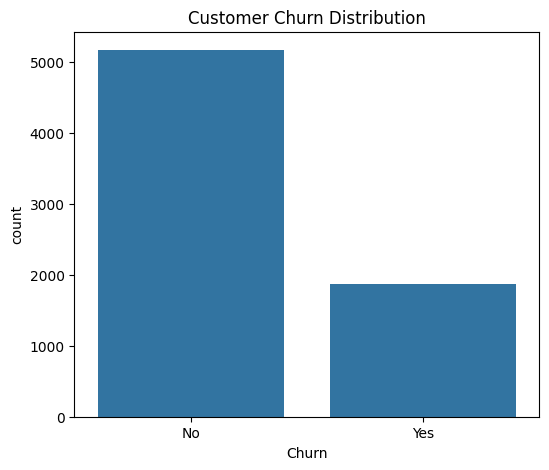

In [79]:
plt.figure(figsize=(6,5))

sns.countplot(data=df,x="Churn")

plt.title("Customer Churn Distribution")

plt.show()

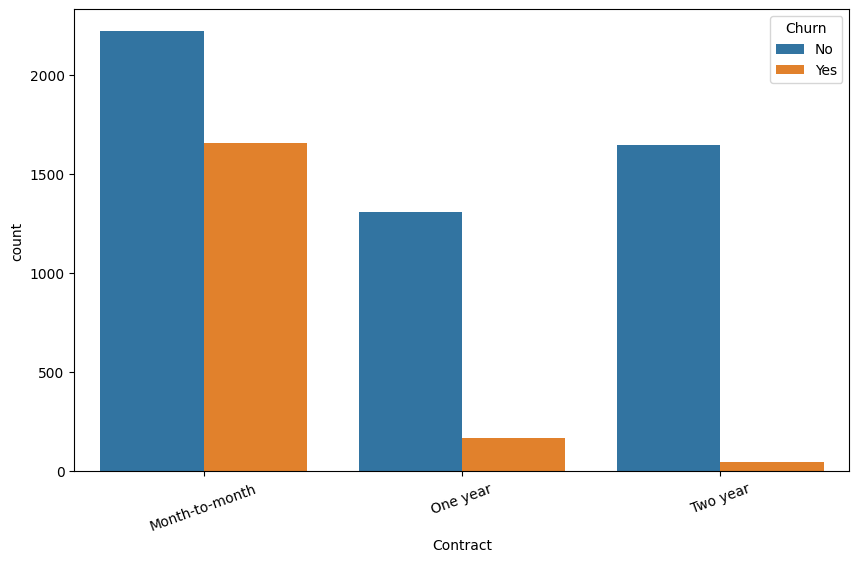

In [80]:
plt.figure(figsize=(10,6))

sns.countplot(data=df,x="Contract",hue="Churn")

plt.xticks(rotation=20)

plt.show()

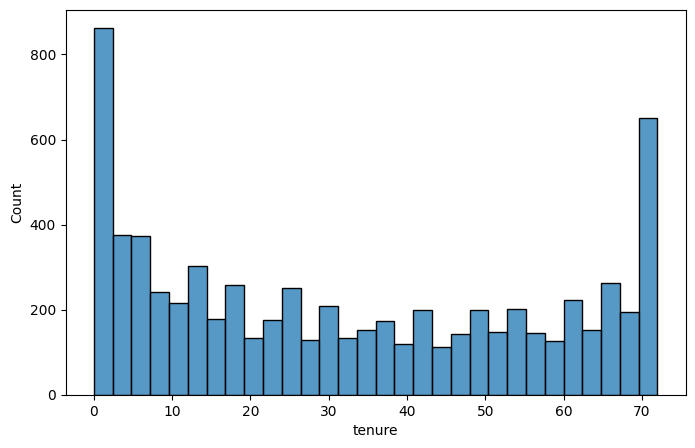

In [81]:
plt.figure(figsize=(8,5))

sns.histplot(df["tenure"],bins=30)

plt.show()

In [82]:
## Handle 'Total Charges': Convert string representations to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [83]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [84]:
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

In [85]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [86]:
#Drop the column to prevent Data Leakage during modeling
df.drop("customerID", axis=1, inplace=True)

In [87]:
#separate the columns
categorical_cols = df.select_dtypes(include="object").columns
numerical_cols = df.select_dtypes(exclude="object").columns

print("Categorical Columns:")
print(categorical_cols)

print("\nNumerical Columns:")
print(numerical_cols)

Categorical Columns:
Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

Numerical Columns:
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')


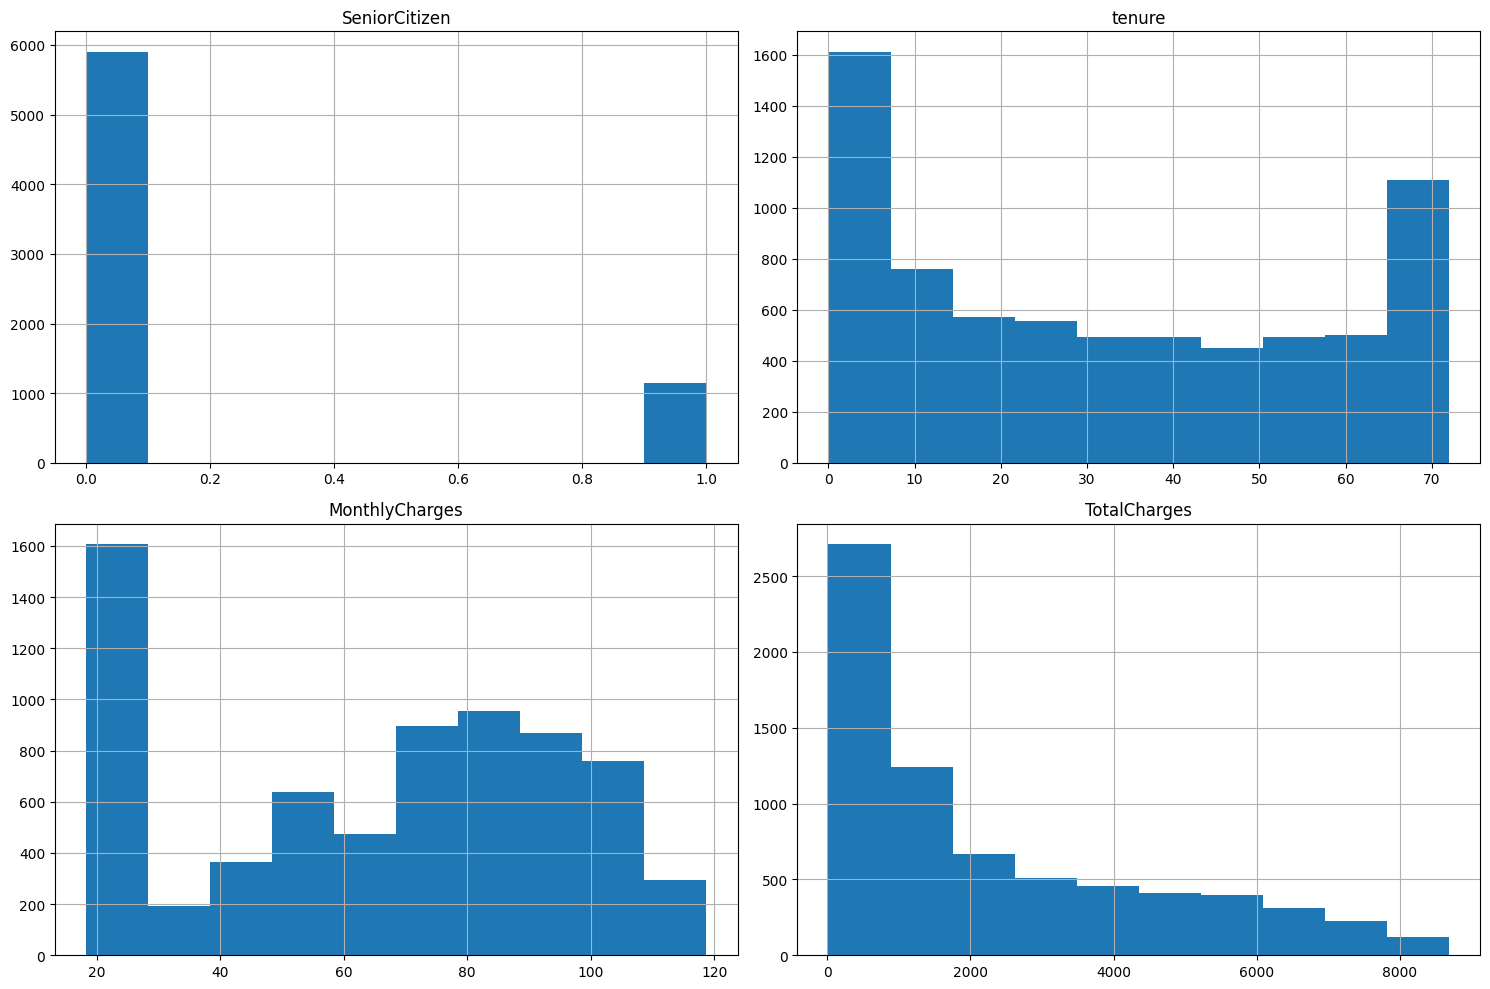

In [88]:
#distripution of numerical values
df[numerical_cols].hist(figsize=(15,10))

plt.tight_layout()

plt.show()

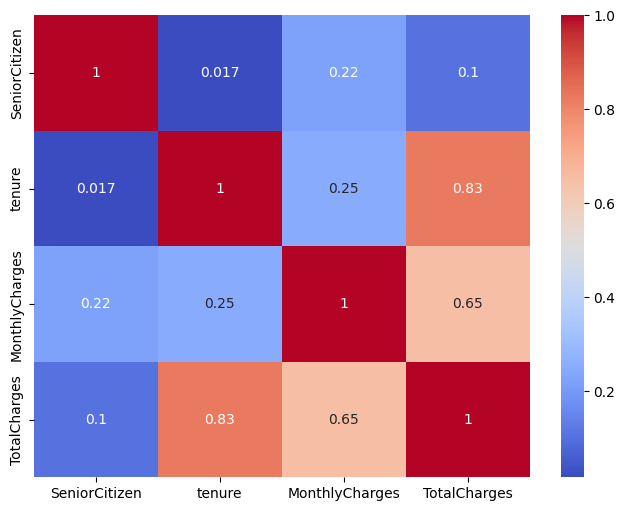

In [89]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[numerical_cols].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [91]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

binary_columns = [
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling",
    "Churn"
]

for col in binary_columns:
    df[col] = le.fit_transform(df[col])

In [94]:
#for catigorical columns(one hot encoding)
df = pd.get_dummies(
    df,
    drop_first=True
)

In [95]:
#check the values
df.head()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,gender_Male,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,0,1,29.85,29.85,0,False,...,False,False,False,False,False,False,False,False,True,False
1,0,0,0,34,1,0,56.95,1889.50,0,True,...,False,False,False,False,False,True,False,False,False,True
2,0,0,0,2,1,1,53.85,108.15,1,True,...,False,False,False,False,False,False,False,False,False,True
3,0,0,0,45,0,0,42.30,1840.75,0,True,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,2,1,1,70.70,151.65,1,False,...,False,False,False,False,False,False,False,False,True,False


In [96]:
df.shape

(7043, 31)

In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7043 non-null   int64  
 1   Partner                                7043 non-null   int64  
 2   Dependents                             7043 non-null   int64  
 3   tenure                                 7043 non-null   int64  
 4   PhoneService                           7043 non-null   int64  
 5   PaperlessBilling                       7043 non-null   int64  
 6   MonthlyCharges                         7043 non-null   float64
 7   TotalCharges                           7043 non-null   float64
 8   Churn                                  7043 non-null   int64  
 9   gender_Male                            7043 non-null   bool   
 10  MultipleLines_No phone service         7043 non-null   bool   
 11  Mult

In [100]:
#data separation
X = df.drop("Churn", axis=1)

y = df["Churn"]

In [101]:
#data partitioning
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [102]:
#standard scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [103]:
#training models
lr = LogisticRegression(random_state=42)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [104]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [105]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [106]:
gb = GradientBoostingClassifier(
    random_state=42
)

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

In [107]:
#models evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def evaluate_model(name, y_true, y_pred):

    print("="*50)

    print(name)

    print("="*50)

    print("Accuracy :", accuracy_score(y_true,y_pred))

    print("Precision :", precision_score(y_true,y_pred))

    print("Recall :", recall_score(y_true,y_pred))

    print("F1 Score :", f1_score(y_true,y_pred))

    print("ROC AUC :", roc_auc_score(y_true,y_pred))

    print()

In [108]:
evaluate_model("Logistic Regression",y_test,lr_pred)

evaluate_model("Decision Tree",y_test,dt_pred)

evaluate_model("Random Forest",y_test,rf_pred)

evaluate_model("Gradient Boosting",y_test,gb_pred)

Logistic Regression
Accuracy : 0.8069552874378992
Precision : 0.6583850931677019
Recall : 0.5668449197860963
F1 Score : 0.6091954022988506
ROC AUC : 0.7302823632746905

Decision Tree
Accuracy : 0.7359829666430092
Precision : 0.5026041666666666
Recall : 0.516042780748663
F1 Score : 0.5092348284960422
ROC AUC : 0.6657508589733654

Random Forest
Accuracy : 0.7934705464868701
Precision : 0.6397306397306397
Recall : 0.5080213903743316
F1 Score : 0.5663189269746647
ROC AUC : 0.7023198739311272

Gradient Boosting
Accuracy : 0.7984386089425124
Precision : 0.6530612244897959
Recall : 0.5133689839572193
F1 Score : 0.5748502994011976
ROC AUC : 0.7074091296597691



In [109]:
#classification report
from sklearn.metrics import classification_report

print(classification_report(y_test,rf_pred))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.51      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.79      1409



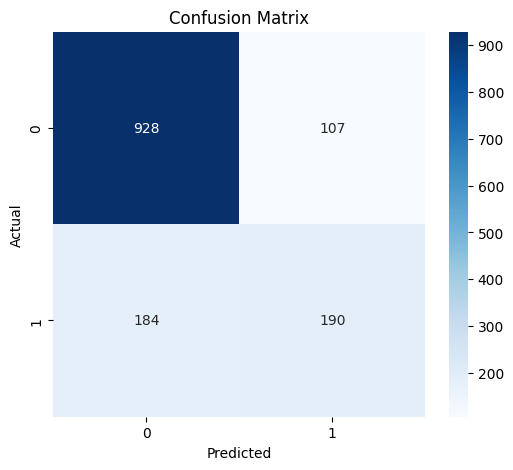

In [110]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,rf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

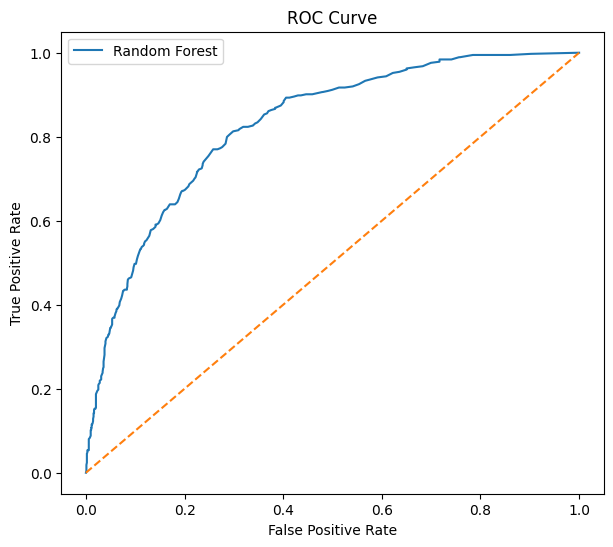

In [111]:
from sklearn.metrics import roc_curve

rf_prob = rf.predict_proba(X_test)[:,1]

fpr,tpr,_ = roc_curve(y_test,rf_prob)

plt.figure(figsize=(7,6))

plt.plot(fpr,tpr,label="Random Forest")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [112]:
results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],

    "Accuracy":[
        accuracy_score(y_test,lr_pred),
        accuracy_score(y_test,dt_pred),
        accuracy_score(y_test,rf_pred),
        accuracy_score(y_test,gb_pred)
    ],

    "Precision":[
        precision_score(y_test,lr_pred),
        precision_score(y_test,dt_pred),
        precision_score(y_test,rf_pred),
        precision_score(y_test,gb_pred)
    ],

    "Recall":[
        recall_score(y_test,lr_pred),
        recall_score(y_test,dt_pred),
        recall_score(y_test,rf_pred),
        recall_score(y_test,gb_pred)
    ],

    "F1":[
        f1_score(y_test,lr_pred),
        f1_score(y_test,dt_pred),
        f1_score(y_test,rf_pred),
        f1_score(y_test,gb_pred)
    ]

})

results.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.806955,0.658385,0.566845,0.609195
3,Gradient Boosting,0.798439,0.653061,0.513369,0.574850
2,Random Forest,0.793471,0.639731,0.508021,0.566319
1,Decision Tree,0.735983,0.502604,0.516043,0.509235


In [114]:
import joblib
import os

# Create the 'models' directory if it doesn't exist
os.makedirs('models', exist_ok=True)

joblib.dump(
    rf,
    "models/random_forest.pkl"
)

['models/random_forest.pkl']

In [115]:
#hyperparameter tuning
from sklearn.model_selection import GridSearchCV

params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}


In [116]:
best_model = grid.best_estimator_

best_pred = best_model.predict(X_test)

print(classification_report(y_test, best_pred))

              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.66      0.51      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [117]:
import joblib

joblib.dump(best_model, "models/customer_churn_model.pkl")
joblib.dump(scaler, "models/scaler.pkl")

['models/scaler.pkl']

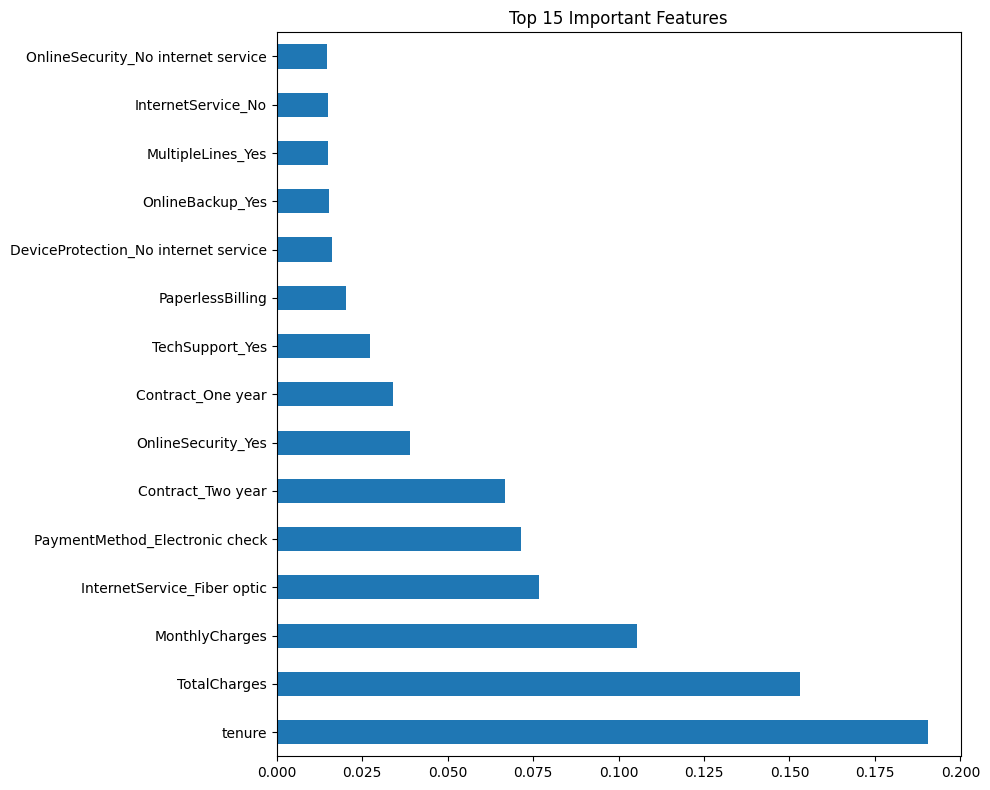

In [118]:
importance = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,8))

importance.head(15).plot(kind="barh")

plt.title("Top 15 Important Features")

plt.tight_layout()

plt.show()

In [120]:
pip install shap

In [121]:
import shap

explainer = shap.TreeExplainer(best_model)

shap_values = explainer.shap_values(X_test)

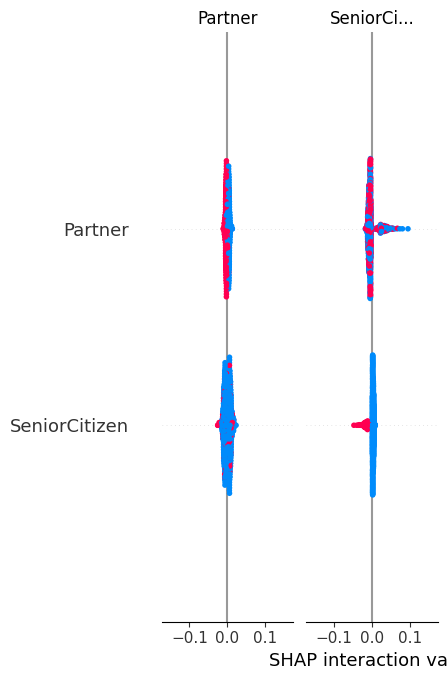

In [122]:
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X.columns
)

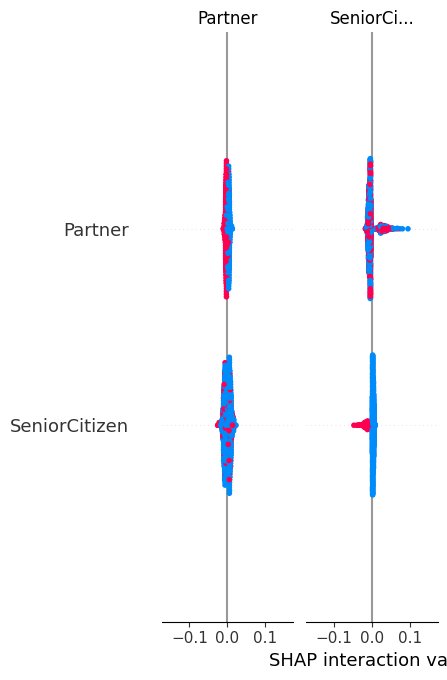

In [124]:
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X.columns,
    plot_type="bar"
)